In [11]:
import pandas as pd
import numpy as np

# Fijar semilla para reproducibilidad
np.random.seed(42)

# Crear un DataFrame simulado con 1000 clientes
churn_df = pd.DataFrame({
    "account_length": np.random.randint(1, 365, 1000),  # Días con la cuenta activa
    "customer_service_calls": np.random.randint(0, 10, 1000),  # Número de llamadas al servicio
    "churn": np.random.choice([0, 1], size=1000, p=[0.8, 0.2])  # 1 = se dio de baja, 0 = sigue activo
})

# Ver las primeras filas
display(churn_df)

,account_length,customer_service_calls,churn
0,103,1,1
1,349,7,0
2,271,1,0
3,107,3,0
4,72,0,0
...,...,...,...
995,161,9,0
996,178,1,0
997,10,8,0
998,261,2,1


In [15]:
# Import KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier

y = churn_df["churn"].values
X = churn_df[["account_length", "customer_service_calls"]].values

# Create a KNN classifier with 6 neighbors
knn = KNeighborsClassifier(n_neighbors=6)

# Fit the classifier to the data
knn.fit(X,y)

KNeighborsClassifier(n_neighbors=6)

In [18]:
# Predict the labels for the X_new
y_pred = knn.predict(X)

# Print the predictions
print("Predictions: {}".format(y_pred)) 

Predictions: [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0

In [12]:
import numpy as np
import pandas as pd
import wooldridge as wd
from sklearn.preprocessing import StandardScaler

# Cargar el conjunto de datos 'wage1' de Wooldridge
df = wd.data('wage1')

# Extraer las variables de interés
X = df[['exper', 'educ']].values  # Variables independientes (experiencia y educación)
y = df['lwage'].values  # Variable dependiente (logaritmo del ingreso)

# Normalizar las variables independientes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Añadir una columna de unos para el término de intercepto
X_scaled = np.c_[np.ones(X_scaled.shape[0]), X_scaled]  # Añadir la intersección

# Función de costo (MSE)
def cost_function(theta, X, y):
    m = len(y)  # Número de observaciones
    predictions = X @ theta  # Predicciones
    error = predictions - y  # Error
    return (1 / (2 * m)) * np.sum(error ** 2)  # MSE

# Gradiente de la función de costo
def gradient(theta, X, y):
    m = len(y)  # Número de observaciones
    predictions = X @ theta  # Predicciones
    error = predictions - y  # Error
    return (1 / m) * (X.T @ error)  # Gradiente

# Inicializar los parámetros
theta = np.zeros(X_scaled.shape[1])  # Inicialización a cero
learning_rate = 0.001  # Tasa de aprendizaje
num_iterations = 1000  # Número de iteraciones

# Almacenar los costos para graficar
costs = []

# Descenso de gradiente
for _ in range(num_iterations):
    cost = cost_function(theta, X_scaled, y)  # Calcular la función de costo
    costs.append(cost)  # Almacenar el costo
    grad = gradient(theta, X_scaled, y)  # Calcular el gradiente
    theta -= learning_rate * grad  # Actualizar los parámetros

# Mostrar resultados
print(f"Parámetros óptimos (theta): {theta}")
print(f"Costo final (MSE): {costs[-1]}")

Parámetros óptimos (theta): [1.02640006 0.05605827 0.15110195]
Costo final (MSE): 0.2920386303585113


Parámetros óptimos (theta): [1.02640006 0.05605827 0.15110195]
Costo final (MSE): 0.2920386303585113


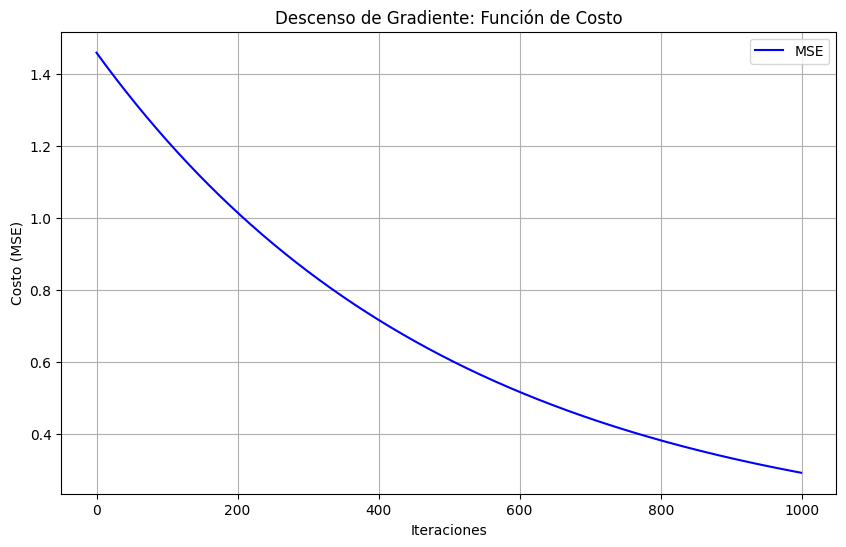

In [13]:
import numpy as np
import pandas as pd
import wooldridge as wd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Cargar el conjunto de datos 'wage1' de Wooldridge
df = wd.data('wage1')

# Extraer las variables de interés
X = df[['exper', 'educ']].values  # Variables independientes (experiencia y educación)
y = df['lwage'].values  # Variable dependiente (logaritmo del ingreso)

# Normalizar las variables independientes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Añadir una columna de unos para el término de intercepto
X_scaled = np.c_[np.ones(X_scaled.shape[0]), X_scaled]  # Añadir la intersección

# Función de costo (MSE)
def cost_function(theta, X, y):
    m = len(y)  # Número de observaciones
    predictions = X @ theta  # Predicciones
    error = predictions - y  # Error
    return (1 / (2 * m)) * np.sum(error ** 2)  # MSE

# Gradiente de la función de costo
def gradient(theta, X, y):
    m = len(y)  # Número de observaciones
    predictions = X @ theta  # Predicciones
    error = predictions - y  # Error
    return (1 / m) * (X.T @ error)  # Gradiente

# Inicializar los parámetros
theta = np.zeros(X_scaled.shape[1])  # Inicialización a cero
learning_rate = 0.001  # Tasa de aprendizaje
num_iterations = 1000  # Número de iteraciones

# Almacenar los costos para graficar
costs = []

# Descenso de gradiente
for _ in range(num_iterations):
    cost = cost_function(theta, X_scaled, y)  # Calcular la función de costo
    costs.append(cost)  # Almacenar el costo
    grad = gradient(theta, X_scaled, y)  # Calcular el gradiente
    theta -= learning_rate * grad  # Actualizar los parámetros

# Mostrar resultados
print(f"Parámetros óptimos (theta): {theta}")
print(f"Costo final (MSE): {costs[-1]}")

# Graficar la función de costo
plt.figure(figsize=(10, 6))
plt.plot(range(num_iterations), costs, label='MSE', color='blue')
plt.title('Descenso de Gradiente: Función de Costo')
plt.xlabel('Iteraciones')
plt.ylabel('Costo (MSE)')
plt.grid()
plt.legend()
plt.show()

Parámetros óptimos (theta): [1.6126 0.1343 0.2647]
Costo final (MSE): 0.1059


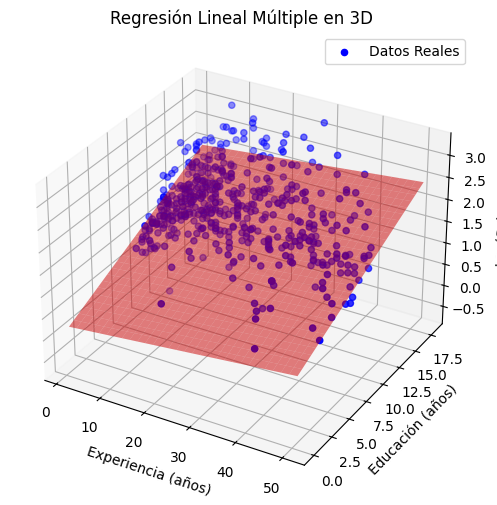

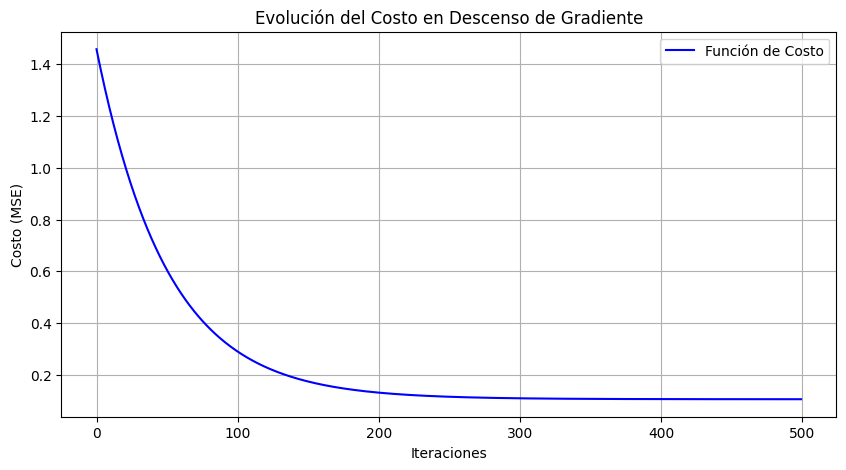

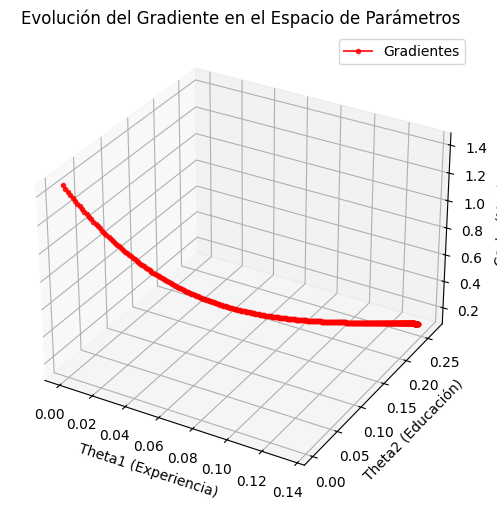

In [14]:
import numpy as np
import pandas as pd
import wooldridge as wd
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Cargar el conjunto de datos 'wage1' de Wooldridge
df = wd.data('wage1')

# Extraer las variables de interés
X = df[['exper', 'educ']].values  # Variables independientes (experiencia y educación)
y = df['lwage'].values  # Variable dependiente (logaritmo del ingreso)

# Normalizar las variables independientes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Añadir una columna de unos para el término de intercepto
X_scaled = np.c_[np.ones(X_scaled.shape[0]), X_scaled]  # Agregar el intercepto

# Función de costo (MSE)
def cost_function(theta, X, y):
    m = len(y)
    predictions = X @ theta
    error = predictions - y
    return (1 / (2 * m)) * np.sum(error ** 2)

# Gradiente de la función de costo
def gradient(theta, X, y):
    m = len(y)
    predictions = X @ theta
    error = predictions - y
    return (1 / m) * (X.T @ error)

# Inicializar los parámetros
theta = np.zeros(X_scaled.shape[1])  # Inicialización a cero
learning_rate = 0.01  # Tasa de aprendizaje
num_iterations = 500  # Número de iteraciones

# Almacenar los costos para graficar
costs = []
theta_history = []  # Para almacenar los valores de theta en cada iteración

# Descenso de gradiente
for _ in range(num_iterations):
    cost = cost_function(theta, X_scaled, y)
    costs.append(cost)
    grad = gradient(theta, X_scaled, y)
    theta -= learning_rate * grad
    theta_history.append(theta.copy())

# Mostrar resultados
print(f"Parámetros óptimos (theta): {theta.round(4)}")
print(f"Costo final (MSE): {round(costs[-1], 4)}")

# ---- GRÁFICA 1: Hiperplano de Regresión en 3D ---- #
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')

# Datos reales
ax.scatter(df['exper'], df['educ'], df['lwage'], c='blue', label='Datos Reales')

# Crear una malla para el hiperplano
exper_range = np.linspace(df['exper'].min(), df['exper'].max(), 30)
educ_range = np.linspace(df['educ'].min(), df['educ'].max(), 30)
exper_grid, educ_grid = np.meshgrid(exper_range, educ_range)

# Normalizar la malla
exper_grid_scaled = (exper_grid - X[:, 0].mean()) / X[:, 0].std()
educ_grid_scaled = (educ_grid - X[:, 1].mean()) / X[:, 1].std()

# Predecir lwage para la malla
lwage_pred = (theta[0] + theta[1] * exper_grid_scaled + theta[2] * educ_grid_scaled)

# Dibujar el hiperplano
ax.plot_surface(exper_grid, educ_grid, lwage_pred, color='red', alpha=0.5)

# Configuración del gráfico
ax.set_xlabel('Experiencia (años)')
ax.set_ylabel('Educación (años)')
ax.set_zlabel('Log(Salario)')
ax.set_title('Regresión Lineal Múltiple en 3D')
ax.legend()
plt.show()


# ---- GRÁFICA 2: Descenso de la Función de Costo ---- #
plt.figure(figsize=(10, 5))
plt.plot(range(num_iterations), costs, color='blue', label='Función de Costo')
plt.xlabel('Iteraciones')
plt.ylabel('Costo (MSE)')
plt.title('Evolución del Costo en Descenso de Gradiente')
plt.legend()
plt.grid()
plt.show()


# ---- GRÁFICA 3: Gradientes ---- #
theta_history = np.array(theta_history)  # Convertir a numpy array
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')

# Dibujar la trayectoria del descenso de gradiente
ax.plot(theta_history[:, 1], theta_history[:, 2], costs, color='red', marker='o', markersize=3, alpha=0.8, label="Gradientes")

# Configuración del gráfico
ax.set_xlabel('Theta1 (Experiencia)')
ax.set_ylabel('Theta2 (Educación)')
ax.set_zlabel('Costo (MSE)')
ax.set_title('Evolución del Gradiente en el Espacio de Parámetros')
ax.legend()
plt.show()

In [15]:
import numpy as np
import pandas as pd
import wooldridge as wd
from sklearn.preprocessing import StandardScaler

# Cargar el conjunto de datos 'wage1' de Wooldridge
df = wd.data('wage1')

# Extraer las variables de interés
X = df[['exper', 'educ']].values  # Variables independientes (experiencia y educación)
y = df['lwage'].values  # Variable dependiente (logaritmo del ingreso)

# Normalizar las variables independientes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Añadir una columna de unos para el término de intercepto
X_scaled = np.c_[np.ones(X_scaled.shape[0]), X_scaled]  # Añadir la intersección

# Función de costo (MSE)
def cost_function(theta, X, y):
    m = len(y)  # Número de observaciones
    predictions = X @ theta  # Predicciones
    error = predictions - y  # Error
    return (1 / (2 * m)) * np.sum(error ** 2)  # MSE

# Gradiente de la función de costo
def gradient(theta, X, y):
    m = len(y)  # Número de observaciones
    predictions = X @ theta  # Predicciones
    error = predictions - y  # Error
    return (1 / m) * (X.T @ error)  # Gradiente

# Inicializar los parámetros
theta = np.zeros(X_scaled.shape[1])  # Inicialización a cero
learning_rate = 0.001  # Tasa de aprendizaje
num_iterations = 1000  # Número de iteraciones

# Almacenar los costos para graficar
costs = []

# Descenso de gradiente
for _ in range(num_iterations):
    cost = cost_function(theta, X_scaled, y)  # Calcular la función de costo
    costs.append(cost)  # Almacenar el costo
    grad = gradient(theta, X_scaled, y)  # Calcular el gradiente
    theta -= learning_rate * grad  # Actualizar los parámetros

# Mostrar resultados
print(f"Parámetros óptimos (theta): {theta}")
print(f"Costo final (MSE): {costs[-1]}")

Parámetros óptimos (theta): [1.02640006 0.05605827 0.15110195]
Costo final (MSE): 0.2920386303585113


In [25]:
import pandas as pd
import plotly.express as px
import wooldridge as wd

# Cargar el conjunto de datos 'wage1' de Wooldridge
df = wd.data('wage2')
display(df)

,wage,hours,IQ,KWW,educ,exper,tenure,age,married,black,south,urban,sibs,brthord,meduc,feduc,lwage
0,769,40,93,35,12,11,2,31,1,0,0,1,1,2.0,8.0,8.0,6.645091
1,808,50,119,41,18,11,16,37,1,0,0,1,1,NaN,14.0,14.0,6.694562
2,825,40,108,46,14,11,9,33,1,0,0,1,1,2.0,14.0,14.0,6.715384
3,650,40,96,32,12,13,7,32,1,0,0,1,4,3.0,12.0,12.0,6.476973
4,562,40,74,27,11,14,5,34,1,0,0,1,10,6.0,6.0,11.0,6.331502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
930,520,40,79,28,16,6,1,30,1,1,1,0,0,1.0,11.0,NaN,6.253829
931,1202,40,102,32,13,10,3,31,1,0,1,1,7,7.0,8.0,6.0,7.091742
932,538,45,77,22,12,12,10,28,1,1,1,0,9,NaN,7.0,NaN,6.287858
933,873,44,109,25,12,12,12,28,1,0,1,0,1,1.0,NaN,11.0,6.771935


In [ ]:
# Crear un gráfico 3D de ingreso vs. experiencia y años de educación
fig = px.scatter_3d(
    df,
    x='exper',        # Experiencia (años)
    y='educ',         # Años de educación
    z='lwage',        # Logaritmo del ingreso (uso logaritmo para normalizar)
    color='wage',    # Color basado en el ingreso logarítmico
    labels={
        'exper': 'Experiencia (años)',
        'educ': 'Años de Educación',
        
        'wage': 'Ingreso ($USD)'
    },
    title='Ingreso (Log) vs. Experiencia y Años de Educación',
    color_continuous_scale=px.colors.sequential.Viridis  # Escala de color
)

# Ajustar el diseño
fig.update_layout(
    scene=dict(
        xaxis_title='Experiencia (años)',
        yaxis_title='Años de Educación',
        zaxis_title='Ingreso ($USD)',
    ),
    width=1000,  # Ancho del gráfico
    height=600   # Altura del gráfico
)

# Mostrar gráfico
fig.show()